# Imports and file paths

In [1]:
# Make sure that we are in the right file path
%cd /home/jupyter-tpeulen/dev/bff/examples/microscopy

/home/jupyter-tpeulen/dev/bff/examples/microscopy


In [2]:
from typing import Tuple, List, Callable

import os
import tqdm

import numpy as np
import numba as nb

import scipy.stats
import scipy.optimize

import matplotlib as mpl
import matplotlib.pylab as plt

import imageio.v3 as iio # To read images incl meat (yummy) data
import cv2               # For faster convolutions
import skimage as ski    # Better than snowboarding

In [3]:
@nb.jit(nopython=True)
def convolve2D(image, kernel, padding=0, strides=1):
    # Cross Correlation
    kernel = np.flipud(np.fliplr(kernel))

    # Gather Shapes of Kernel + Image + Padding
    xKernShape = kernel.shape[0]
    yKernShape = kernel.shape[1]
    xImgShape = image.shape[0]
    yImgShape = image.shape[1]

    # Shape of Output Convolution
    xOutput = int(((xImgShape - xKernShape + 2 * padding) / strides) + 1)
    yOutput = int(((yImgShape - yKernShape + 2 * padding) / strides) + 1)
    output = np.zeros((xOutput, yOutput))

    # Apply Equal Padding to All Sides
    if padding != 0:
        imagePadded = np.zeros((image.shape[0] + padding*2, image.shape[1] + padding*2))
        imagePadded[int(padding):int(-1 * padding), int(padding):int(-1 * padding)] = image
        print(imagePadded)
    else:
        imagePadded = image

    # Iterate through image
    for y in range(image.shape[1]):
        # Exit Convolution
        if y > image.shape[1] - yKernShape:
            break
        # Only Convolve if y has gone down by the specified Strides
        if y % strides == 0:
            for x in range(image.shape[0]):
                # Go to next row once kernel is out of bounds
                if x > image.shape[0] - xKernShape:
                    break
                try:
                    # Only Convolve if x has moved by the specified Strides
                    if x % strides == 0:
                        output[x, y] = (kernel * imagePadded[x: x + xKernShape, y: y + yKernShape]).sum()
                except:
                    break

    return output

In [4]:
def plot_image_with_custom_axes(image_data, cmap='magma', pixel_size_x=1, pixel_size_y=1, label=""):
    """
    Plot an image with custom axes spacing.

    Parameters:
        image_data (ndarray): The image data to be plotted.
        cmap (str, optional): The colormap to use for the image. Default is 'hot'.
        left_margin (float, optional): Left margin for the axes. Default is 0.2.
        right_margin (float, optional): Right margin for the axes. Default is 0.05.
        bottom_margin (float, optional): Bottom margin for the axes. Default is 0.1.
        top_margin (float, optional): Top margin for the axes. Default is 0.05.
        horizontal_space (float, optional): Spacing between subplots horizontally. Default is 0.02.
        vertical_space (float, optional): Spacing between subplots vertically. Default is 0.02.
        pixel_size_x (float, optional): Pixel size for x-axis. Default is 1.
        pixel_size_y (float, optional): Pixel size for y-axis. Default is 1.

    Returns:
        None
    """
    rows, cols = image_data.shape
    xticks = np.arange(0, cols) * pixel_size_x
    yticks = np.arange(0, rows) * pixel_size_y

    # Calculate the extent using the pixel sizes
    extent = [0, cols * pixel_size_x, 0, rows * pixel_size_y]

    # Plot the image using the specified colormap and extent
    plt.imshow(image_data, cmap=cmap, interpolation='nearest', extent=extent, label=label)

    plt.show()


In [5]:
def normal_distribution(x, mean, std_dev, scale, offset=0):
    return scale*scipy.stats.norm.pdf(x, loc=mean, scale=std_dev) + offset

In [6]:
@nb.jit(nopython=True)
def wdev2(src, kernel):
    nx, ny = src.shape
    kx, ky = kernel.shape
    hkx, hky = kx // 2, ky // 2
    k1 = np.clip(kernel / np.sum(kernel), 1e-12, 1e12)
    res = np.zeros_like(src, dtype=np.float64)
    for ix in range(0 + hkx, nx - hkx):
        for iy in range(0 + hky, ny - hky):
            roi = np.clip(src[ix - hkx: ix + hkx, iy - hky: iy + hky], 1e-12, 1e12)
            kn = k1 * np.sum(roi)
            wres = (roi - kn) / np.clip(np.sqrt(roi), 1, 1e6)
            w2 = np.sum(wres**2.0)
            res[ix, iy] = w2
    return res

In [7]:
def compute_kernel(
    spacing: int = 4,          
    theta: float = 0.0,        
    plot_kernel: bool = False, 
    sigma: float = 1.5,        
    nxy: int = 64,
    w12: Tuple[float, float] = (3.0, 6.0)
) -> np.ndarray:
    """
    Compute a 2D convolution kernel with periodic stripes.

    The function generates a 2D convolution kernel by creating periodic stripes
    of ones with a specified spacing and applies Gaussian blur to the stripes.
    The resulting kernel can be rotated by a specified angle.

    Parameters:
        spacing (int): Line spacing in pixels between the periodic stripes. 
                       Default is 4.
        theta (float): Rotation angle in degrees to apply to the kernel. 
                       Default is 0.0 (no rotation).
        plot_kernel (bool): If True, the function will display a 2x2 plot of the 
                            intermediate kernel stages for visualization purposes. 
                            Default is False.
        sigma (float): The standard deviation for the Gaussian blur applied to the 
                       periodic stripes. A larger value results in a smoother kernel. 
                       Default is 2.0.
        nxy (int): The size of the square kernel grid along the x and y axes. 
                   The generated kernel will have dimensions (2*nxy) x (2*nxy). 
                   Default is 32.

    Returns:
        np.ndarray: The 2D convolution kernel as a NumPy array. The values are 
                    normalized, so the sum of the kernel elements is 1.0.

    Note:
        - The function uses NumPy and SciPy libraries for array manipulation and 
          Gaussian filtering.
        - The kernel can be used for 2D convolution operations to create interesting 
          visual effects.

    Example:
        # Compute a 2D convolution kernel with spacing=8, rotate by 45 degrees, and plot it
        kernel = compute_kernel(spacing=8, theta=45, plot_kernel=True)

    """
    w1, w2 = w12
    w2 /= spacing
    x, y = np.mgrid[-nxy // 2 :nxy // 2 :1, -nxy // 2 :nxy // 2 : 1]
    pos = np.dstack((x, y))
    rv = scipy.stats.multivariate_normal(
        mean=[0.0, 0.0], 
        cov=[[(nxy/w1)**2.0, 0.0],[0.0, (nxy/w2)**2.0]], 
        allow_singular=False
    )
    w = rv.pdf(pos)
    w = w.astype(np.float64)
    x = np.arange(-nxy, nxy)
    stripes = np.zeros_like(w, dtype=np.float64)
    stripes[:, nxy // 2 - spacing // 2] = 1
    stripes[:, nxy // 2 + spacing // 2 + spacing % 2] = 1
    kernel0 = stripes * w
    kernelb = scipy.ndimage.gaussian_filter(kernel0, sigma)
    kernel = scipy.ndimage.rotate(kernelb, theta, reshape=False, order=0)

    kernel /= kernel.sum()

    if plot_kernel:
        fig, axs = plt.subplots(2, 2)
        axs[0, 0].imshow(w)
        axs[0, 1].imshow(kernel0)
        axs[1, 0].imshow(kernelb)
        axs[1, 1].imshow(kernel)
        print("Kernel shape:", kernel.shape)
        plt.show()
        
    return kernel

In [8]:
#kernel = compute_kernel(16, 45, plot_kernel=True, sigma=1.0, nxy=20, w12=(9, 20))

In [9]:
def get_correlation(
    img: np.ndarray,
    spacings: np.ndarray,
    angles: np.ndarray,
    matching_mode: int = 1,
    **kwargs
) -> Tuple[np.ndarray, List[List[np.ndarray]]]:
    """
    Compute the correlation between an input image and an evenly spaced grid at a 
    set of grid angles using template matching.

    The function calculates the correlation between the input image and a set of 
    convolution kernels generated by a periodic stripe pattern. The kernels are 
    rotated at evenly spaced angles to create a grid for template matching against 
    the input image.

    Parameters:
        img (np.ndarray): The input image on which template matching will be performed. 
                          It should be a 2D NumPy array.
        spacings (np.ndarray): An array of integers specifying the line spacings 
                               between periodic stripes in the convolution kernels. 
                               Default is np.arange(2, 24, 1).
        n_angles (int): The number of evenly spaced grid angles in degrees at which 
                        the kernels will be rotated for template matching. 
                        Default is 32.

    Returns:
        Tuple[np.ndarray, List[List[np.ndarray]]]: A tuple containing two elements:
            1. correlation_results (np.ndarray): A 4D NumPy array of shape (num_spacings, 
               num_angles, img_height, img_width). It contains the correlation results 
               of the template matching for each spacing and angle.
            2. kernels (List[List[np.ndarray]]): A nested list of the generated kernels 
               for each spacing and angle combination. It has a shape of 
               (num_spacings, num_angles), and each element is a 2D NumPy array representing 
               the convolution kernel.

    Note:
        - The function uses the `compute_kernel` function to generate convolution kernels 
          with periodic stripe patterns.
        - The `cv2.filter2D` function from the OpenCV library is used for template matching.
        - The correlation results represent the matching scores between the input image 
          and each rotated kernel. Higher scores indicate better matches.

    Example:
        # Compute the correlation between `input_image` using default spacings and angles
        correlation_results, kernels = get_correlation(input_image)

        # Compute the correlation using custom spacings and a different number of angles
        spacings = np.array([4, 8, 12])
        num_angles = 16
        correlation_results, kernels = get_correlation(input_image, spacings, num_angles)
    """
    # Perform the cross-correlation (template matching)
    correlation_results = list()
    plot_kernels = False
    na, ns = len(angles), len(spacings)
    kernels = list()
    nx, ny = img.shape
    correlation_results = np.zeros((ns, na, nx, ny), dtype=np.float64)
    for id, spacing in tqdm.tqdm(enumerate(spacings)):
        ks = []
        for ia, theta in enumerate(angles):
            kernel = compute_kernel(spacing=spacing, theta=theta, plot_kernel=plot_kernels, **kwargs)
            kernel /= np.sum(kernel)
            kernel *= np.sum(img)
            # print(n_kernel, n_img-n_kernel)
            if matching_mode == 0:
                kernel_scaled = img.sum() * kernel
                out = cv2.matchTemplate(img, kernel_scaled, method=cv2.TM_CCOEFF_NORMED)
                n_out_x, n_out_y = out.shape
                correlation_results[id, ia, :n_out_x, :n_out_y] = out
            elif matching_mode == 1:
                s = img.sum()
                kernel_scaled = s * kernel
                correlation_result = cv2.filter2D(src=img, kernel=kernel_scaled, ddepth=-1)
                correlation_results[id, ia, :, :] = correlation_result
            elif matching_mode == 2:
                correlation_result = twoIstar(src=img, kernel=kernel)
                correlation_results[id, ia, :, :] = correlation_result
            elif matching_mode == 3:
                correlation_result = wdev2(src=img, kernel=kernel)
                correlation_results[id, ia, :, :] = correlation_result
            elif matching_mode == 4:
                s = img.sum()
                kernel_scaled = s * kernel
                correlation_result = convolve2D(img, kernel_scaled)
                correlation_results[id, ia, :, :] = correlation_result
            ks.append(kernel)
        kernels.append(ks)
    correlation_results = np.array(correlation_results)
    return correlation_results, kernels


In [10]:
def threshold_correlations(
    correlations: np.ndarray,
    filter: Callable = ski.filters.threshold_otsu,
    verbose: int = 0
) -> Tuple[float, np.ndarray]:
    """
    Apply a thresholding algorithm to the sum of correlations for grid-based template matching.

    The function takes the sum of correlation results obtained from grid-based template 
    matching and applies a thresholding algorithm to create a binary mask. The binary mask 
    highlights regions of interest that have strong correlation scores.

    Parameters:
        correlations (np.ndarray): A 4D NumPy array of shape (num_spacings, num_angles, 
                                    img_height, img_width) containing the correlation results 
                                    obtained from grid-based template matching.
        filter (Callable): The thresholding function to be used for threshold calculation. 
                           It should accept a 2D NumPy array as input and return a scalar 
                           threshold value. Default is ski.filters.threshold_otsu.
        verbose (int): An integer flag to control the visualization of intermediate images. 
                       Set to 0 for no visualization, 1 to display the correlation image, 
                       and the binary mask. Default is 0.

    Returns:
        Tuple[float, np.ndarray]: A tuple containing two elements:
            1. threshold (float): The computed threshold value used to generate the binary 
                                  mask from the correlation results.
            2. binary (np.ndarray): A 2D NumPy array representing the binary mask created 
                                    using the threshold. It highlights regions of interest 
                                    with strong correlation scores.

    Note:
        - The `correlations` parameter is expected to be the result of the `get_correlation` 
          function, which contains the correlation results of the template matching process.
        - The `filter` parameter allows the user to specify a different thresholding function 
          from the scikit-image library if desired.
        - The binary mask is generated by comparing the sum of correlations with the computed 
          threshold value. Regions with correlation scores higher than the threshold are set 
          to 1 (True), while regions with lower scores are set to 0 (False).

    Example:
        # Compute the correlation results using `get_correlation` function
        correlations, _ = get_correlation(input_image)

        # Apply thresholding using the default threshold_otsu function
        threshold, binary_mask = threshold_correlations(correlations)

        # Apply thresholding using a custom thresholding function
        from skimage.filters import threshold_isodata
        threshold, binary_mask = threshold_correlations(correlations, filter=threshold_isodata)

    """
    i1 = correlations.sum(axis=(0,1))
    i2 = i1 / np.max(i1)
    gray = ski.util.img_as_uint(i2)
    threshold = ski.filters.threshold_otsu(gray) # delivers very high threshold
    #threshold = ski.filters.threshold_isodata(gray) # works extremely well
    #threshold = ski.filters.threshold_yen(gray) # delivers even higher threshold
    print(threshold)
    binary = gray > threshold
    if verbose > 0:
        plt.imshow(binary)
        plt.show()
    return threshold, binary

In [11]:
def color_map(pixel_intensity, feature1, feature2):
    # Define a mapping for each feature to a specific color range (0-255).
    # Adjust these mappings based on the range of your features and the desired color output.
    feature1_color = int((feature1 - min_feature1) / (max_feature1 - min_feature1) * 255)
    feature2_color = int((feature2 - min_feature2) / (max_feature2 - min_feature2) * 255)

    # Combine the features and pixel intensity to form the final color.
    red = int(pixel_intensity * 255)
    green = feature1_color
    blue = feature2_color

    return red, green, blue


In [12]:
@nb.jit(nopython=True)
def twoIstar(src, kernel):
    nx, ny = src.shape
    kx, ky = kernel.shape
    hkx, hky = kx // 2, ky // 2
    k1 = np.clip(kernel / np.sum(kernel), 1e-12, 1e12)
    res = np.zeros_like(src, dtype=np.float64)
    for ix in range(0 + hkx, nx - hkx):
        for iy in range(0 + hky, ny - hky):
            roi = np.clip(src[ix - hkx: ix + hkx, iy - hky: iy + hky], 1e-12, 1e12)
            ns = np.sum(roi)
            kn = k1 * ns
            twoIstar =  2 * np.sum(roi * np.log(roi / kn))
            res[ix, iy] = twoIstar
    return res

In [13]:
def get_rois(
    image, # Binarized image
    minimum_area: int = 4000,
    verbose: int = 0
):
    # remove artifacts connected to image border
    cleared = ski.segmentation.clear_border(image)

    # label image regions
    label_image = ski.measure.label(cleared)
    # to make the background transparent, pass the value of `bg_label`,
    # and leave `bg_color` as `None` and `kind` as `overlay`
    image_label_overlay = ski.color.label2rgb(label_image, image=image, bg_label=0)

    selected_regions = list()
    for region in ski.measure.regionprops(label_image):
        # take regions with large enough areas
        if region.area >= minimum_area:
            # draw rectangle around segmented coins
            selected_regions.append(region)

    if verbose > 0:
        fig, ax = plt.subplots()
        for idx, region in enumerate(selected_regions):
            minr, minc, maxr, maxc = region.bbox
            rect = mpl.patches.Rectangle(
                (minc, minr), 
                maxc - minc, 
                maxr - minr, 
                fill=False, 
                edgecolor='red', 
                linewidth=2
            )
            ax.add_patch(rect)
            # Add the ROI number to the bounding box
            ax.text(minc + 5, minr + 5, f"ROI {idx+1}", color='red', fontsize=10, weight='bold', verticalalignment='top')

        ax.imshow(image_label_overlay)
        ax.set_axis_off()
        plt.tight_layout()
        plt.show()
    return selected_regions

In [14]:
def prior_score(d, mean=190, std_dev=20, scale: float = 100.0):
    return scale * ((d - mean) / std_dev) ** 2.0

# Load image

In [375]:
# Adjust for other files
tiff_file_path = "dImage2.2.tif"

Filename: dImage2.2.tif
pixel_size_x [nm]: 20.4
pixel_size_y [nm]: 20.4


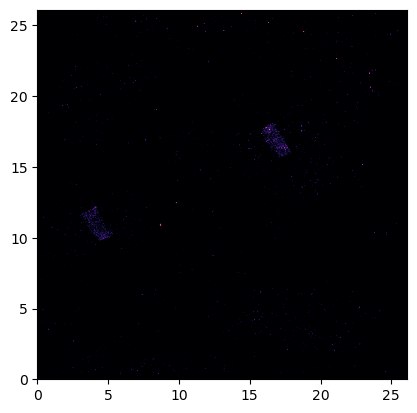

In [376]:
# Read data of file
image = iio.imread(tiff_file_path)
# Read meta data of file (Needed here ass the pixel sizes)
properties = iio.improps(tiff_file_path, extension=".tif")
idx, idy = properties.spacing # spacing is inverse of pixel distance
pixel_size_x, pixel_size_y = 1. / idx, 1. / idy
print("Filename: {}".format(tiff_file_path))
print("pixel_size_x [nm]: {:1.1f}".format(pixel_size_x * 1000.0))
print("pixel_size_y [nm]: {:1.1f}".format(pixel_size_y * 1000.0))
plot_image_with_custom_axes(image, pixel_size_x=pixel_size_x, pixel_size_y=pixel_size_y, label=tiff_file_path)

# Find ROIs by cross correlation with templates

4it [00:04,  1.10s/it]


17969


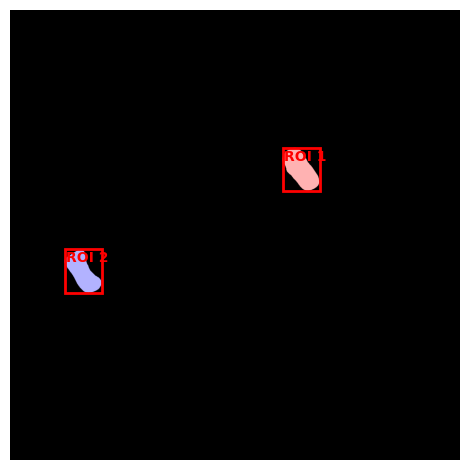

In [377]:
# Define finer angles
angles_coarse: np.ndarray = np.linspace(-90, 90, 16)
spacings_coarse: np.ndarray = np.arange(2, 16, 4)
correlations, kernels = get_correlation(image, spacings_coarse, angles_coarse, sigma=0.8)

# Integrate over angles and spacings
corr_image = np.sum(correlations, axis=(0,1))

# plot correlation image and identify ROIs
threshold, binary = threshold_correlations(correlations, verbose=0)
selected_regions = get_rois(binary, verbose=1)

# Analyze ROIs in detail

In [378]:
# Define fine angles and spacings
angles: np.ndarray = np.arange(0, 180 + 1, 2)
spacings: np.ndarray = np.arange(1, 19, 1)

# Compute spacing axis
spacings_d = spacings * pixel_size_x * 1000.0

Kernel shape: (96, 96)


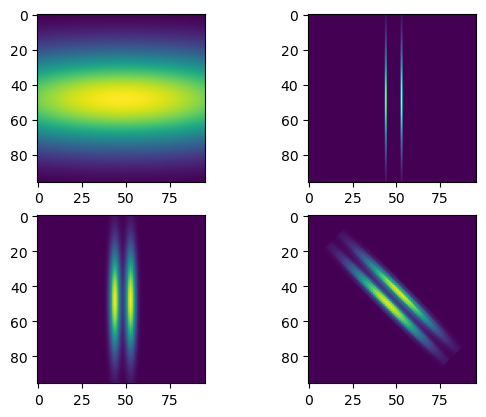

In [379]:
# Variables for plotting (etc.)
plot_cbar = False # If set to True plots a color bar for the distributions

# Define kernel properties
sigma = 2.0   # The stripes are blurred a bit to capture cases where hits are slightly of the stripe
nxy = 96      # This defines the kernel size. If the kernel is too small large spacings cannot be covered. If it is too big you loose spatial resolution
w12 = 5, 12   # Control the width of the stripes

# Helper variables
padding: int = nxy // 2

# Display kernel for settings
kernel = compute_kernel(9, 45, plot_kernel=True, sigma=sigma, nxy=nxy, w12=w12)

In [380]:
# Compute correlations of cropped ROIs
roi_correlations = list() # stores the correlations/likelihood of the ROIs with kernels
roi_intensities = list() # stores the intensities of the cropped ROIs
roi_nbr_events = list()  # stores the number of events in roi (number of localizations)
for roi_idx, selected_region in enumerate(selected_regions):
    # Extract the bounding box coordinates
    minr, minc, maxr, maxc = selected_region.bbox

    # Crop the smaller image from the original image
    cropped_image = np.copy(image[minr-padding:maxr+padding, minc-padding:maxc+padding])
    roi_nbr = np.sum(cropped_image)
    roi_nbr_events.append(roi_nbr)
    cropped_image /= roi_nbr
    cropped_image[padding:-padding, padding:-padding] # * (1 - selected_region.image)
    roi_intensities.append(cropped_image)

    # Save cropped image to file
    tiff_file_path_base = os.path.splitext(tiff_file_path)[0]
    iio.imwrite(tiff_file_path_base + '_roi-' + str(roi_idx) + '_crop.tif', cropped_image)
        
    correlations, _ = get_correlation(cropped_image, spacings, angles, sigma=sigma, nxy=nxy, w12=w12, matching_mode=1)
    c = np.copy(correlations)
    roi_correlations.append(c)

18it [00:08,  2.03it/s]
18it [00:08,  2.03it/s]


183.60000315792007


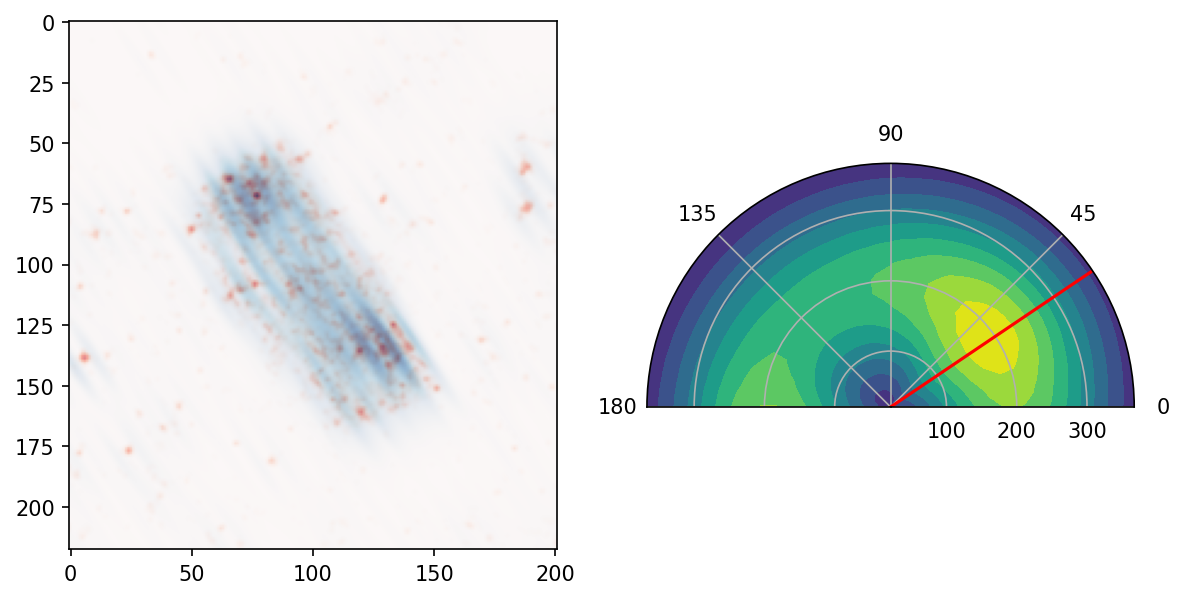

183.60000315792007


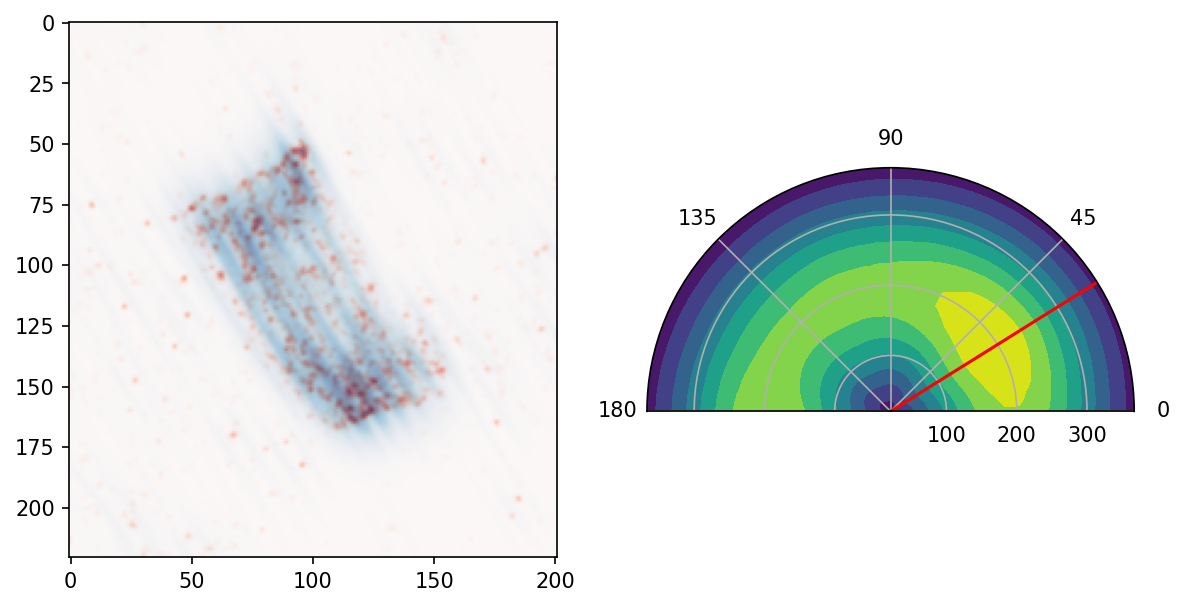

In [402]:
cm_posteriors = list()
optimal_angel_idx = list()

for roi_idx, roi_intensity in enumerate(roi_intensities):
    correlation_roi = np.copy(roi_correlations[roi_idx])
    
    nd, na, nx, ny = correlation_roi.shape

    fig = plt.figure(figsize=(8, 6), dpi=150)
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122, projection='polar')
    #ax3 = fig.add_subplot(123)
    
    ax2.set_thetamin(0)
    ax2.set_thetamax(180)
    
    #ax1.imshow(np.fliplr(roi_intensity))
    ax1.imshow(roi_intensity, cmap='Reds')
    
    # Define prior
    N = nx * ny # roi_nbr_events[roi_idx]
    cm_posterior = - N / 2 * np.log(1-correlation_roi**2.0)
    prior_d = np.array([prior_score(d, mean=200, std_dev=90, scale = 1.0) for d in spacings_d])
    prior_d /= sum(prior_d)

    # Define weight of prior
    prior_d *= np.max(cm_posterior) * 0.25
    
    for di, d in enumerate(spacings_d):
        s = np.abs(cm_posterior[di, :, :, :].sum())
        cm_posterior[di, :, :, :] -= prior_d[di]
    cm_posteriors.append(cm_posterior)
    
    cm = cm_posterior.sum(axis=(2, 3))
    cm = np.exp(cm)
    
    label_format = '{:,.0f}'
    xticks_loc = [0, np.pi / 4, np.pi * 2 / 4, np.pi * 3 / 4, np.pi]
    ax2.set_xticks(xticks_loc)
    ax2.set_xticklabels(['0', '45', '90', '135', '180'])

    yticks_loc = [0, 100, 200, 300]
    ax2.set_yticks(yticks_loc)
    ax2.set_yticklabels([label_format.format(x) for x in yticks_loc])
    
    ia = 0
    for i in range(cm.shape[1]):
        if np.max(cm[:, i]) > np.max(cm[:, ia]):
            ia = i
    id = 0
    for i in range(cm.shape[0]):
        if cm[i, ia] > cm[id, ia]:
            id = i
    
    optimal_angel_idx.append(ia)
    ags = [np.radians(angles[ia])] * len(spacings_d)
    
    r, theta = np.meshgrid(spacings_d, np.radians(angles))
    pcm = ax2.contourf(theta, r, cm.T, levels=8)
    ax2.plot(ags, spacings_d, 'r')
    if plot_cbar:
        cbar = fig.colorbar(pcm, ax=ax2, orientation="horizontal", pad=0.0)
        cbar.ax.locator_params(nbins=3)

    print(spacings_d[id])

    kernel = compute_kernel(spacings[id], angles[ia], plot_kernel=False, sigma=1.0, nxy=nxy, w12=(9, 9))
    img_conv = cv2.filter2D(src=roi_intensity, kernel=kernel, ddepth=-1)
    ax1.imshow(img_conv, alpha=0.5, cmap='Blues')
    
    fig.tight_layout()

    fn = tiff_file_path_base + '_distribution_roi-' + str(roi_idx)
    plt.savefig(fn + '.png')

    plt.show()

In [403]:
def find_min_idx(x):
    k = x.argmin()
    ncol = x.shape[1]
    return k/ncol, k%ncol

In [ ]:
img_r = np.zeros*(

## Analysis of marginal distribution

Distance [nm]: 189.8
Standard deviation [nm]: 94.2
Scale: 15.1
Offset: 0.0
Distance [nm]: 191.1
Standard deviation [nm]: 93.4
Scale: 14.8
Offset: 0.0


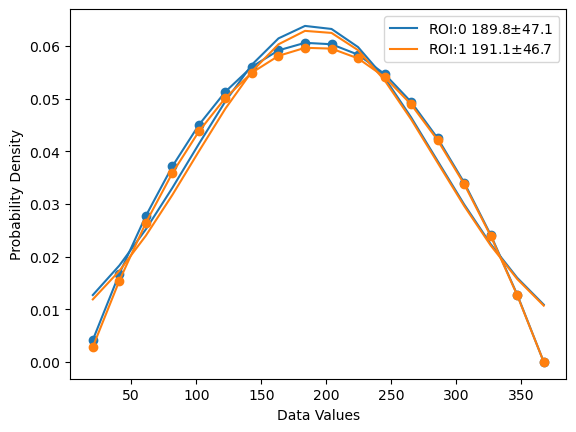

In [397]:
for roi_idx, cm_posterior in enumerate(cm_posteriors):
    data = -cm_posterior[:, optimal_angel_idx[roi_idx], :, :].sum(axis=(1, 2))
    data /= np.abs(data.sum())
    data = np.exp(-data)
    data -= np.min(data)
    
    p0 = 180, 200, 0.001, 0.0000 # Distance, Sigma, scale, offset
    bounds = 0, (350, 500, 1e6, 10)
    
    # Fit the normal distribution to the data
    mean_estimate, std_dev_estimate = scipy.optimize.curve_fit(normal_distribution, spacings_d, data, p0=p0, maxfev = 5000, bounds=bounds)
    
    # Extract the estimated parameters
    mean_fit, std_dev_fit, scale_fit, offset = mean_estimate
    
    # Plot the fitted normal distribution
    x = spacings_d
    ax = plt.gca()
    color = next(ax._get_lines.prop_cycler)['color']
    plt.plot(spacings_d, data, 'o-', color=color)
    plt.plot(x, normal_distribution(x, mean_fit, std_dev_fit, scale_fit, offset), '-', label='ROI:{:d} {:1.1f}$\pm${:1.1f}'.format(roi_idx, mean_fit, std_dev_fit / 2.0), color=color)
    
    plt.xlabel('Data Values')
    plt.ylabel('Probability Density')
    plt.legend()
    # plt.show()
    
    print("Distance [nm]: {:.1f}".format(mean_fit))
    print("Standard deviation [nm]: {:.1f}".format(std_dev_fit))
    print("Scale: {:.1f}".format(scale_fit))
    print("Offset: {:.1f}".format(offset))

# TODO - image reconstruction

In [ ]:
idx_spacing = 8
idx_angle = 8
d = spacings_d[idx_spacing]
a = angles[idx_angle]

tiff_file_path_base = os.path.splitext(tiff_file_path)[0]

p = np.copy(correlation_roi[idx_spacing, idx_angle])
kernel = compute_kernel(idx_spacing, a, plot_kernel=False, sigma=sigma, nxy=nxy, w12=w12)
p[0: kernel.shape[0], 0: kernel.shape[1]] += kernel * 20000000
iio.imwrite(tiff_file_path_base + '_roi-' + str(roi_idx) + "_d({:1.1f}nm)_a-({:1.1f}deg)".format(d, a) + '_crop.tif', p)

plt.imshow(p)

In [ ]:
nd, na, nrx, nry = correlation_roi.shape

In [ ]:
E = np.zeros((nd, na), dtype=np.float64)
for di, d in enumerate(spacings_d):
    for ai, a in enumerate(angles):
        img = correlation_roi[di,ai, :, :]
        marg = np.histogramdd(np.ravel(img), bins = 256)[0]/img.size
        marg = list(filter(lambda p: p > 0, np.ravel(marg)))
        E[di, ai] = -np.sum(np.multiply(marg, np.log2(marg)))

In [ ]:
extent = [angles[0], angles[-1], spacings_d[0], spacings_d[-1]]
plt.imshow(np.exp(-E[:, :]), cmap="viridis") #, extent=extent)